# BEAD Random Forest — No State-Level Features

Replaces coarse state-level features with finer-grained equivalents:

| Dropped | Replaced by |
|---|---|
| `state_num_providers` | `frac_competitor_qualifying`, `frac_wired_qualifying`, `frac_fiber_qualifying`, `frac_sat_only_qualifying` from `fp_approved.competition_analysis` — fraction of a project's locations that have each competitor type present |
| `state_population` | `POPDEN_RUR_wmean`, `POPDEN_COU_wmean` from `2020_UA_COUNTY.xlsx` — county-level population density, weighted by location count |

Single model (not split by technology). Features:
- **Project**: `miles_per_location`, `pct_aerial`, `technology`, `pct_cai`
- **Competition** (location-level, averaged per project): `frac_competitor_qualifying`, `frac_competitor_qualifying_no_sat`, `frac_wired_qualifying`, `frac_fiber_qualifying`, `frac_sat_only_qualifying`
- **Geography** (county wmeans): `POPDEN_RUR_wmean`, `POPDEN_COU_wmean`, `rucc_code_wmean`, `poverty_rate_wmean`

In [66]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

client = bigquery.Client(project='broadband-data')
print('Connected to BigQuery: broadband-data')

Connected to BigQuery: broadband-data


In [67]:
# ── BigQuery ───────────────────────────────────────────────────────────────────
df_projects = client.query("""
SELECT project_id, state, bead_support,
       estimated_miles_aerial_fiber, estimated_miles_buried_fiber
FROM `broadband-data.fp_approved.deployment_projects`
""").to_dataframe()

df_locations = client.query("""
SELECT project_id, COUNT(*) AS funded_locations,
    SAFE_CAST(APPROX_TOP_COUNT(CAST(technology AS STRING),1)[OFFSET(0)].value AS FLOAT64) AS technology
FROM `broadband-data.fp_approved.locations`
GROUP BY project_id
""").to_dataframe()

# Competition fractions — location-level flags averaged to project level
df_comp = client.query("""
SELECT
    project_id,
    AVG(IF(competitor_present_qualifying, 1.0, 0.0))         AS frac_competitor_qualifying,
    AVG(IF(competitor_present_qualifying_no_sat, 1.0, 0.0))  AS frac_competitor_qualifying_no_sat,
    AVG(IF(present_at_location, 1.0, 0.0))                   AS frac_present_at_location,
    AVG(IF(wired_competitor_present_qualifying, 1.0, 0.0))    AS frac_wired_qualifying,
    AVG(IF(fiber_competitor_present_qualifying, 1.0, 0.0))    AS frac_fiber_qualifying,
    AVG(IF(sat_only_competitor_qualifying, 1.0, 0.0))         AS frac_sat_only_qualifying
FROM `broadband-data.fp_approved.competition_analysis`
GROUP BY project_id
""").to_dataframe()

# CAI count per project
df_cai = client.query("""
SELECT project_id, COUNT(*) AS cai_count
FROM `broadband-data.fp_approved.loc_cai`
GROUP BY project_id
""").to_dataframe()

# Location → county mapping for geographic wmeans
df_loc_county = client.query("""
SELECT loc.project_id,
    SUBSTR(nbm.block_geoid, 1, 5) AS county_id,
    COUNT(*) AS location_count
FROM `broadband-data.fp_approved.locations` loc
JOIN `broadband-data.fcc_bdc.nbm_hive` nbm ON loc.location_id = nbm.location_id
WHERE nbm.period = '2025_06'
GROUP BY loc.project_id, county_id
""").to_dataframe()

print(f'Projects:    {df_projects.shape[0]}')
print(f'Competition: {df_comp.shape[0]} projects')
print(f'CAI:         {df_cai.shape[0]} projects')
print(f'Loc-county:  {df_loc_county.shape[0]} rows')

Projects:    5740
Competition: 5228 projects
CAI:         5744 projects
Loc-county:  12098 rows


In [68]:
# ── Local county files ─────────────────────────────────────────────────────────

# RUCC (long → wide)
df_rucc_raw = pd.read_csv('../Ruralurbancontinuumcodes2023.csv', encoding='ISO-8859-1')
df_rucc_wide = df_rucc_raw.pivot_table(
    index=['FIPS','State','County_Name'], columns='Attribute', values='Value', aggfunc='first'
).reset_index()
df_rucc_wide.columns.name = None
df_rucc_wide['county_id'] = df_rucc_wide['FIPS'].astype(str).str.zfill(5)
df_rucc_wide['RUCC_2023'] = pd.to_numeric(df_rucc_wide['RUCC_2023'], errors='coerce')
df_rucc = df_rucc_wide[['county_id','RUCC_2023']].rename(columns={'RUCC_2023':'rucc_code'})

# Natural amenities — topography
df_topo_raw = pd.read_excel('../natamenf.xls').iloc[103:]
df_topo_raw.columns = df_topo_raw.iloc[0]
df_topo_raw = df_topo_raw[1:].reset_index(drop=True)
df_topo_raw['county_id'] = df_topo_raw['FIPS Code'].astype(str).str.zfill(5)
df_topo_raw = df_topo_raw.rename(columns={'TOPOG - Z':'topography_z','Water area * 100':'water_area_pct'})
df_topo = df_topo_raw[['county_id','topography_z']].copy()
df_topo['topography_z'] = pd.to_numeric(df_topo['topography_z'], errors='coerce')

# Road ruggedness
df_rugged_raw = pd.read_csv('../ruggedness-scales-2020-tracts.csv', encoding='ISO-8859-1')
df_rugged_raw['county_id'] = df_rugged_raw['CountyFIPS23'].astype(str).str.zfill(5)
df_rugged = df_rugged_raw.groupby('county_id')[['RRS']].mean().reset_index()

# ACS poverty
df_pov_raw = pd.read_csv(
    '../ACSDT5Y2024.B17001_2026-07-15T133739/ACSDT5Y2024.B17001-Data.csv'
).iloc[1:]
df_pov_raw['county_id'] = df_pov_raw['GEO_ID'].str[-5:]
df_pov_raw['B17001_001E'] = pd.to_numeric(df_pov_raw['B17001_001E'], errors='coerce')
df_pov_raw['B17001_002E'] = pd.to_numeric(df_pov_raw['B17001_002E'], errors='coerce')
df_pov_raw['poverty_rate'] = df_pov_raw['B17001_002E'] / df_pov_raw['B17001_001E'].replace(0, np.nan)
df_poverty = df_pov_raw[['county_id','poverty_rate']].dropna()

# Population density (replaces state_population)
df_housing = pd.read_excel('../2020_UA_COUNTY.xlsx')
df_housing['STATE']  = df_housing['STATE'].astype(str).str.zfill(2)
df_housing['COUNTY'] = df_housing['COUNTY'].astype(str).str.zfill(3)
df_housing['county_id'] = df_housing['STATE'] + df_housing['COUNTY']
# POPDEN_RUR = rural pop density, POPDEN_COU = county-wide pop density
df_housing = df_housing[['county_id','POPDEN_RUR','POPDEN_COU']].dropna(subset=['county_id'])

# Combined county table
df_county = (
    df_rucc
    .merge(df_topo,    on='county_id', how='outer')
    .merge(df_rugged,  on='county_id', how='outer')
    .merge(df_poverty, on='county_id', how='outer')
    .merge(df_housing, on='county_id', how='outer')
)
print(f'County table: {df_county.shape}')
print(df_county[['rucc_code','topography_z','RRS','poverty_rate','POPDEN_RUR','POPDEN_COU']].isna().sum())

County table: (3249, 7)
rucc_code        16
topography_z    138
RRS             105
poverty_rate     27
POPDEN_RUR       15
POPDEN_COU       15
dtype: int64


In [69]:
# ── Project-level geographic weighted means ────────────────────────────────────
GEO_COLS = ['rucc_code','topography_z','RRS','poverty_rate','POPDEN_RUR','POPDEN_COU']

df_lc = df_loc_county.merge(df_county[['county_id'] + GEO_COLS], on='county_id', how='left')

for col in GEO_COLS:
    df_lc[f'{col}_x_n'] = df_lc[col].fillna(df_lc[col].median()) * df_lc['location_count']

proj_geo = df_lc.groupby('project_id').agg(
    geo_n      = ('location_count', 'sum'),
    n_counties = ('county_id', 'nunique'),
    **{f'{c}_x_n': (f'{c}_x_n', 'sum') for c in GEO_COLS}
).reset_index()

for col in GEO_COLS:
    proj_geo[f'{col}_wmean'] = proj_geo[f'{col}_x_n'] / proj_geo['geo_n']
    proj_geo.drop(columns=[f'{col}_x_n'], inplace=True)

print(f'Geographic project features: {proj_geo.shape}')
print(proj_geo[[f'{c}_wmean' for c in GEO_COLS]].describe().round(2))

Geographic project features: (5665, 9)
       rucc_code_wmean  topography_z_wmean  RRS_wmean  poverty_rate_wmean  \
count           5665.0              5665.0     5665.0              5665.0   
mean              4.27                0.22       1.63                0.13   
std               2.62                1.08       0.81                0.05   
min                1.0               -1.19        1.0                0.04   
25%                2.0               -0.74        1.0                 0.1   
50%                4.0                0.17       1.25                0.13   
75%               6.12                1.08        2.0                0.16   
max                9.0                1.84        5.0                0.41   

       POPDEN_RUR_wmean  POPDEN_COU_wmean  
count            5665.0            5665.0  
mean              45.57            250.81  
std               41.28            735.56  
min                 0.0              0.04  
25%                16.6             29.57  
50%

In [70]:
# ── Merge + feature engineering ────────────────────────────────────────────────
df = df_projects.merge(df_locations, on='project_id', how='left')
df = df.merge(df_comp,              on='project_id', how='left')
df = df.merge(df_cai,               on='project_id', how='left')
df = df.merge(proj_geo,             on='project_id', how='left')

df['funded_locations'] = df['funded_locations'].fillna(0)
df['technology']       = df['technology'].fillna(0)
df['cai_count']        = df['cai_count'].fillna(0)

aerial = df['estimated_miles_aerial_fiber'].fillna(0)
buried = df['estimated_miles_buried_fiber'].fillna(0)
df['total_fiber_miles']  = aerial + buried
df['pct_aerial']         = (aerial / df['total_fiber_miles'].replace(0, np.nan)).fillna(0)
df['miles_per_location'] = (df['total_fiber_miles'] / df['funded_locations'].replace(0, np.nan)).fillna(0)
df['pct_cai']            = (df['cai_count'] / df['funded_locations'].replace(0, np.nan)).fillna(0)

# Fill geo and competition NaNs with medians
geo_wmean_cols = [f'{c}_wmean' for c in GEO_COLS]
comp_cols = [c for c in df.columns if c.startswith('frac_')]
for col in geo_wmean_cols + comp_cols:
    df[col] = df[col].fillna(df[col].median())

# Target
df['funding_per_location'] = df['bead_support'] / df['funded_locations'].replace(0, np.nan)
df = df.dropna(subset=['funding_per_location'])
#low, high = df['funding_per_location'].quantile([0.025, 0.975])
#df = df[(df['funding_per_location'] >= low) & (df['funding_per_location'] <= high)]

df['log_funding'] = np.log1p(df['funding_per_location'])

print(f'Samples: {df.shape[0]}')
print(f'Competition cols: {comp_cols}')
print(f'Geo wmean cols:   {geo_wmean_cols}')

Samples: 5715
Competition cols: ['frac_competitor_qualifying', 'frac_competitor_qualifying_no_sat', 'frac_present_at_location', 'frac_wired_qualifying', 'frac_fiber_qualifying', 'frac_sat_only_qualifying']
Geo wmean cols:   ['rucc_code_wmean', 'topography_z_wmean', 'RRS_wmean', 'poverty_rate_wmean', 'POPDEN_RUR_wmean', 'POPDEN_COU_wmean']


Variance explained by state (eta²):
                                   eta_squared  pct_var_by_state
feature                                                         
topography_z_wmean                      0.6302              63.0
RRS_wmean                               0.5594              55.9
POPDEN_RUR_wmean                        0.3602              36.0
poverty_rate_wmean                      0.3169              31.7
pct_aerial                              0.3008              30.1
frac_competitor_qualifying              0.2428              24.3
log_funding                             0.2278              22.8
frac_sat_only_qualifying                0.2264              22.6
POPDEN_COU_wmean                        0.1992              19.9
technology                              0.1946              19.5
frac_competitor_qualifying_no_sat       0.1779              17.8
rucc_code_wmean                         0.1629              16.3
frac_wired_qualifying                   0.1349        

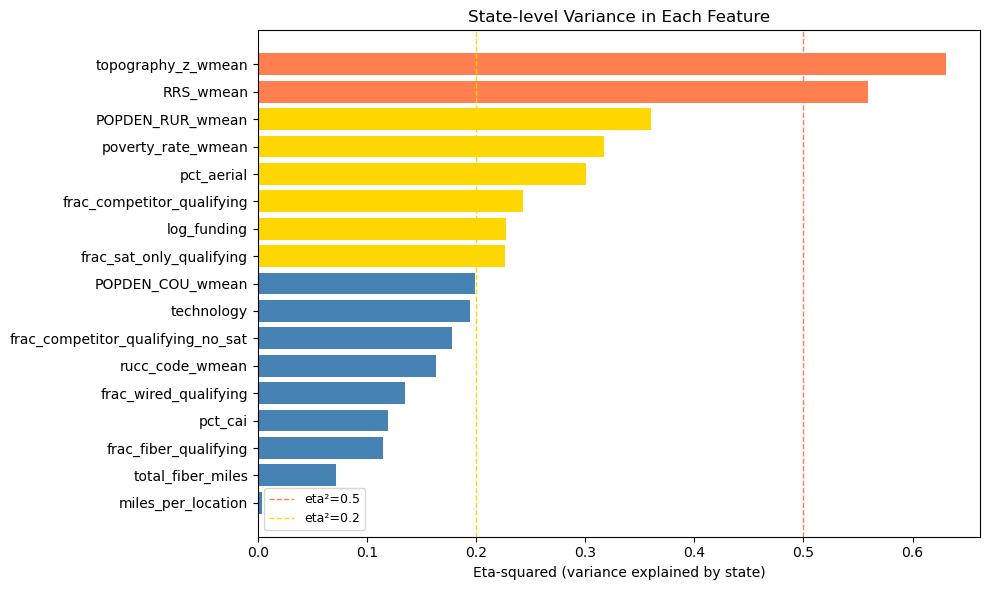

In [71]:
# ── How much does each feature correlate with state? ──────────────────────────
# Eta-squared: proportion of feature variance explained by state membership.
# eta² ≈ 0 → feature varies within states (good)  |  eta² ≈ 1 → state proxy (bad)

CHECK_COLS = [
    "miles_per_location", "total_fiber_miles", "pct_aerial", "technology", "pct_cai",
    "frac_competitor_qualifying", "frac_competitor_qualifying_no_sat",
    "frac_wired_qualifying", "frac_fiber_qualifying", "frac_sat_only_qualifying",
    "POPDEN_RUR_wmean", "POPDEN_COU_wmean",
    "rucc_code_wmean", "topography_z_wmean", "RRS_wmean", "poverty_rate_wmean",
    "log_funding",  # target — how state-explained is the outcome itself?
]

def eta_squared(col, data, group_col="state"):
    """Eta-squared: fraction of variance in col explained by group_col."""
    s = data[col].fillna(data[col].median())
    grand_mean = s.mean()
    ss_total = ((s - grand_mean) ** 2).sum()
    if ss_total == 0:
        return np.nan
    # group means and sizes -> SS_between
    gstats = s.groupby(data[group_col]).agg(["mean", "count"])
    ss_between = (gstats["count"] * (gstats["mean"] - grand_mean) ** 2).sum()
    return ss_between / ss_total

rows = []
for col in CHECK_COLS:
    rows.append({"feature": col, "eta_squared": eta_squared(col, df)})

eta_df = (pd.DataFrame(rows)
          .set_index("feature")
          .sort_values("eta_squared", ascending=False))
eta_df["pct_var_by_state"] = (eta_df["eta_squared"] * 100).round(1)

print("Variance explained by state (eta²):")
print(eta_df.round(4).to_string())

high = eta_df[eta_df["eta_squared"] > 0.5]
if len(high):
    print(f"High state-correlation (eta² > 0.5): {high.index.tolist()}")
else:
    print("No features with eta² > 0.5")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["coral" if v > 0.5 else "gold" if v > 0.2 else "steelblue"
          for v in eta_df["eta_squared"]]
ax.barh(eta_df.index[::-1], eta_df["eta_squared"][::-1], color=colors[::-1])
ax.axvline(0.5, color="coral", linestyle="--", linewidth=1, label="eta²=0.5")
ax.axvline(0.2, color="gold",  linestyle="--", linewidth=1, label="eta²=0.2")
ax.set_xlabel("Eta-squared (variance explained by state)")
ax.set_title("State-level Variance in Each Feature")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig_state_eta_squared.pdf", bbox_inches="tight")
plt.savefig("fig_state_eta_squared.png", dpi=150, bbox_inches="tight")
plt.show()

In [72]:
# ── Features and model ─────────────────────────────────────────────────────────
FEATURE_COLS = [
    # Project-level (no state aggregation)
    'miles_per_location',
    'pct_aerial',
    'technology',
    'pct_cai',
    # Competition — location-level flags averaged per project (replaces state_num_providers)
    'frac_competitor_qualifying',
    'frac_competitor_qualifying_no_sat',
    'frac_wired_qualifying',
    'frac_fiber_qualifying',
    'frac_sat_only_qualifying',
    # Geography — county wmeans (replaces state_population)
    'POPDEN_RUR_wmean',
    'POPDEN_COU_wmean',
    'rucc_code_wmean',
    'poverty_rate_wmean',
]

X = df[FEATURE_COLS].fillna(0)
y = df['log_funding']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)

r2   = r2_score(y_te, y_pred)
cv   = cross_val_score(rf, X, y, cv=kf, scoring='r2')
rmse = np.sqrt(mean_squared_error(np.expm1(y_te), np.expm1(y_pred)))
mae  = mean_absolute_error(np.expm1(y_te), np.expm1(y_pred))

print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'N = {len(X)}')
print(f'Test R²  (log): {r2:.4f}')
print(f'CV R²   (log): {cv.mean():.4f} ± {cv.std():.4f}')
print(f'RMSE (real $): ${rmse:,.0f}')
print(f'MAE  (real $): ${mae:,.0f}')

Features (13): ['miles_per_location', 'pct_aerial', 'technology', 'pct_cai', 'frac_competitor_qualifying', 'frac_competitor_qualifying_no_sat', 'frac_wired_qualifying', 'frac_fiber_qualifying', 'frac_sat_only_qualifying', 'POPDEN_RUR_wmean', 'POPDEN_COU_wmean', 'rucc_code_wmean', 'poverty_rate_wmean']
N = 5715
Test R²  (log): 0.3673
CV R²   (log): 0.4450 ± 0.0473
RMSE (real $): $5,962
MAE  (real $): $2,642


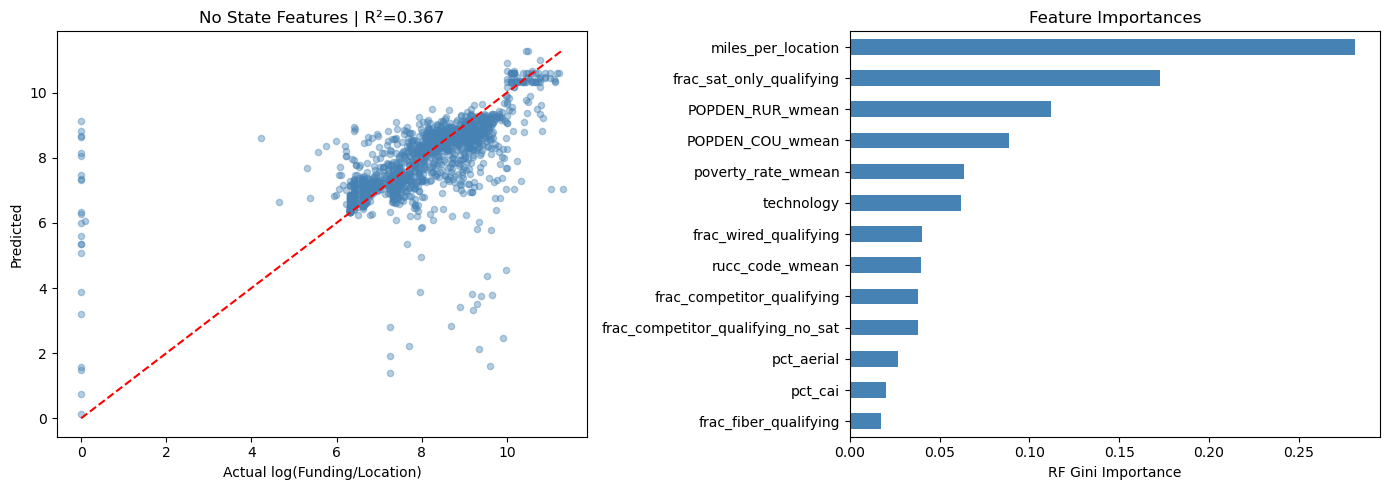

Saved fig_no_state_features.{pdf,png}


In [73]:
# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pred vs actual
axes[0].scatter(y_te, y_pred, alpha=0.4, s=20, color='steelblue')
lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--')
axes[0].set_xlabel('Actual log(Funding/Location)')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'No State Features | R²={r2:.3f}')

# Feature importance
imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
imp.plot.barh(ax=axes[1], color='steelblue')
axes[1].set_xlabel('RF Gini Importance')
axes[1].set_title('Feature Importances')

plt.tight_layout()
plt.savefig('fig_no_state_features.pdf', bbox_inches='tight')
plt.savefig('fig_no_state_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_no_state_features.{pdf,png}')

## Feature Descriptions

### Project structure
- **** — Total fiber miles (aerial + buried) divided by the number of funded locations. Captures infrastructure density: a high value means each location requires more cable to reach, which drives up per-location cost.
- **** — Fraction of fiber miles that are aerial (strung on poles) rather than buried. Aerial fiber costs roughly \–40k/mile; buried costs \–150k/mile. This is one of the strongest unit-cost drivers in fiber construction.
- **** — Dominant technology type across the project's funded locations (FCC code: 40 = Cable/HFC, 50 = Fiber, 61 = Satellite/LEO, 71 = Fixed Wireless). Retained as a single model is fit across all technology types.
- **** — Fraction of funded locations that are Community Anchor Institutions (schools, libraries, hospitals, etc.), drawn from . CAI locations may require higher-capacity or more reliable connections, potentially affecting per-location cost.

### Competition (location-level, averaged per project)
*Source:  — one row per funded location, aggregated to project level by taking the mean of each binary flag. Replaces the coarse  count.*

- **** — Fraction of the project's locations that already have a qualifying competitor present (i.e., a provider meeting BEAD speed/latency thresholds). Higher values indicate more competitive areas; projects here may face pressure to justify their cost.
- **** — Same as above but excluding satellite providers. Distinguishes genuine terrestrial competition from satellite coverage, which is often treated differently in BEAD eligibility.
- **** — Fraction of locations with a qualifying *wired* competitor (fiber, cable, or DSL meeting thresholds). Wired competition is a stronger signal of existing infrastructure than wireless.
- **** — Fraction of locations with a qualifying *fiber* competitor specifically. Areas with existing fiber face the most direct like-for-like competition.
- **** — Fraction of locations where satellite is the *only* qualifying competitor. These are the most isolated locations; LEO satellite (e.g., Starlink) is often the last-resort technology assigned after fiber and fixed wireless.

### Geography (county-level, location-count weighted means)
*Source: local county files joined via FCC NBM block GEOIDs. Each project spans one or more counties; features are weighted by how many funded locations fall in each county. Replaces the coarse  count.  and  were excluded after showing eta² > 0.5 — they were primarily state-level signals rather than within-state variation.*

- **** — Location-count-weighted mean rural population density (persons per square mile of rural land area) across the counties in the project. Lower rural density = more spread-out, harder-to-reach locations.
- **** — Location-count-weighted mean county-wide population density. Complements  by capturing overall county context, not just rural land.
- **** — Location-count-weighted mean Rural-Urban Continuum Code (USDA ERS, 2023). Scale 1–9: 1 = counties in large metro areas, 9 = most rural/remote. Higher values indicate more isolated project areas.
- **** — Location-count-weighted mean county poverty rate (ACS 5-Year 2024, table B17001). Serves as a proxy for geographic remoteness and infrastructure underinvestment; poorer counties tend to have less existing conduit, fewer contractors, and longer haul distances.

### Excluded features
- **`total_fiber_miles`** — Absolute project scale in fiber miles. Excluded because per-location scale is already captured by `miles_per_location`, and raw total miles conflates project size with cost density.




BigQuery tables:                                                                                                                                                      
  - fp_approved.deployment_projects — project metadata (state, bead_support, aerial/buried miles)                                                                         
  - fp_approved.locations — location counts and dominant technology per project
  - fp_approved.competition_analysis — location-level competitor flags (aggregated to project fractions)                                                                  
  - fp_approved.loc_cai — CAI location counts per project                                                                                                               
  - fcc_bdc.nbm_hive (period=2025_06) — maps location_id → block_geoid for county identification

  Local files:
  - Ruralurbancontinuumcodes2023.csv — RUCC codes by county
  - natamenf.xls — topography Z-score by county (loaded but topography_z_wmean excluded from model)
  - ruggedness-scales-2020-tracts.csv — road ruggedness RRS by county (loaded but RRS_wmean excluded)
  - ACSDT5Y2024.B17001-Data.csv — ACS poverty rate by county
  - 2020_UA_COUNTY.xlsx — rural and county-wide population density by county

  The join key between BQ and local files is county_id (5-digit FIPS), derived from SUBSTR(nbm.block_geoid, 1, 5).
